# Инструменты для работы с языком

... или зачем нужна предобработка

Предобработка особенно актуальна при работе с текстами.

## Задача: классификация твитов по тональности

У нас есть выборка из твитов.
Нам известна эмоциональная окраска каждого твита из выборки: положительная или отрицательная. Задача состоит в построении модели, которая по тексту твита предсказывает его эмоциональную окраску.

Классификацию по тональности используют в рекомендательных системах, чтобы понять, понравилось ли людям кафе, кино, etc.

Скачиваем выборку ([источник](http://study.mokoron.com/)): [положительные](https://www.dropbox.com/s/fnpq3z4bcnoktiv/positive.csv?dl=0), [отрицательные](https://www.dropbox.com/s/r6u59ljhhjdg6j0/negative.csv).

In [78]:
from pathlib import Path
from urllib.request import urlretrieve

urls = {
    "positive.csv": "https://www.dropbox.com/s/fnpq3z4bcnoktiv/positive.csv?dl=1",
    "negative.csv": "https://www.dropbox.com/s/r6u59ljhhjdg6j0/negative.csv?dl=1",
}

for filename, url in urls.items():
    path = Path(filename)
    if path.exists() and path.stat().st_size > 0:
        print(f"{filename}: файл уже есть")
    else:
        print(f"Скачиваю {filename}...")
        urlretrieve(url, filename)


positive.csv: файл уже есть
negative.csv: файл уже есть


In [79]:
import pandas as pd
import numpy as np

from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [80]:
pd.read_csv('positive.csv', sep=';', header=None, nrows=5).head()


,0,1,2,3,4,5,6,7,8,9,10,11
0,408906692374446080,1386325927,pleease_shut_up,"@first_timee хоть я и школота, но поверь, у на...",1,0,0,0,7569,62,61,0
1,408906692693221377,1386325927,alinakirpicheva,"Да, все-таки он немного похож на него. Но мой ...",1,0,0,0,11825,59,31,2
2,408906695083954177,1386325927,EvgeshaRe,RT @KatiaCheh: Ну ты идиотка) я испугалась за ...,1,0,1,0,1273,26,27,0
3,408906695356973056,1386325927,ikonnikova_21,"RT @digger2912: ""Кто то в углу сидит и погибае...",1,0,1,0,1549,19,17,0
4,408906761416867842,1386325943,JumpyAlex,@irina_dyshkant Вот что значит страшилка :D\nН...,1,0,0,0,597,16,23,1


Откроем файлы и создадим массив из текстов и правильных меток для твитов:
сначала идут положительные твиты, потом отрицательные.

In [81]:
# загружаем положительные твиты
positive = pd.read_csv('positive.csv', sep=';', usecols=[3], names=['text'])
positive['label'] = ['positive'] * len(positive) # устанавливаем метки

# загружаем отрицательные твиты
negative = pd.read_csv('negative.csv', sep=';', usecols=[3], names=['text'])
negative['label'] = ['negative'] * len(negative) # устанавливаем метки

# соединяем вместе
df = pd.concat ([ positive , negative ])

Посмотрим на полученные данные:

In [82]:
df.sample(5, random_state=42)

,text,label
100170,мыс на меня обиделась:(\nя ей даже ничего не с...,negative
105843,"аааааааааааааааааааа,не хочу на работу :(",negative
60463,"У меня какой-то особенный вид ушей! :D, некото...",positive
98352,@simonovkon он неплохой человек в жизни. Я ра...,negative
113055,"RT @Darina_Lo: Домааааа\nЕхали на такси, пели ...",positive


Разбиваем данные на обучающую и тестовую выборки с помощью функции ```train_test_split()``` из **sklearn**:


In [83]:
x_train, x_test, y_train, y_test = train_test_split(
    df.text,
    df.label,
    test_size=0.25,
    random_state=42,
    stratify=df.label,
)


## Baseline: классификация необработанных n-грамм

* Получим преобразование предложений в численный вектор, с которым может работать стандартный алгоритм машинного обучения, такой как логистическая регрессия.
* Для этого познакомимся с понятием n-gram - самыми мелкими элементами предложения, с которыми можно работать.
* Подсчитав количество этих n-грам в предложениях, получим искомые численные представления.

## Что такое n-граммы:

Самые мелкие структуры языка, с которыми работаем, называются **n-граммами**.
У n-граммы есть параметр n - количество слов, которые попадают в такое представление текста.
* Если n = 1 - то смотрим на то, сколько раз каждое слово встретилось в тексте, получаем _униграммы_
* Если n = 2 - то смотрим на то, сколько раз каждая пара подряд идущих слов, встретилась в тексте, получаем _биграммы_

Функция для работы с n-граммами реализована в библиотеке **nltk** (Natural Language ToolKit), импортируем эту функцию:


In [84]:
from nltk import ngrams

Прежде чем получать n-граммы, нужно разделить предложение на отдельные слова.  Для этого используем метод ```split()```.

In [85]:
sentence = 'Если б мне платили каждый раз'.split()
sentence

['Если', 'б', 'мне', 'платили', 'каждый', 'раз']

Чтобы получить n-грамму для такой последовательности, используем функцию ```ngrams()```.

На вход передается два параметра:
* лист с разделенным на отдельные слова предложением (у нас он хранится в переменной ```sent```);
* параметр n, определяющий, какой тип n-грамм мы хотим получить.


Чтобы полученный объект отобразить, делаем из него ```list```.

In [86]:
list(ngrams(sentence, 1)) # униграммы

[('Если',), ('б',), ('мне',), ('платили',), ('каждый',), ('раз',)]

Аналогично мы можем получить биграммы - для этого заменяем параметр **n** в функции **ngrams** с 1 на 2.

In [87]:
list(ngrams(sentence, 2)) # биграммы

[('Если', 'б'),
 ('б', 'мне'),
 ('мне', 'платили'),
 ('платили', 'каждый'),
 ('каждый', 'раз')]

In [88]:
list(ngrams(sentence, 3)) # триграммы

[('Если', 'б', 'мне'),
 ('б', 'мне', 'платили'),
 ('мне', 'платили', 'каждый'),
 ('платили', 'каждый', 'раз')]

In [89]:
list(ngrams(sentence, 5)) # ... пентаграммы?

[('Если', 'б', 'мне', 'платили', 'каждый'),
 ('б', 'мне', 'платили', 'каждый', 'раз')]

### Векторизаторы

Векторизатор преобразует слово или набор слов в числовой вектор, понятный алгоритму машинного обучения, который привык работать с числовыми табличными данными.

На рисунке представлен пример преобразования слов в двумерный вектор: каждому слову соответствует точка на плоскости.

<a href="https://drive.google.com/uc?id=1ukv-FTj0jeVdcgVlOaNBocUfNuYGGVZg
" target="_blank"><img src="https://drive.google.com/uc?id=1ukv-FTj0jeVdcgVlOaNBocUfNuYGGVZg"
alt="IMAGE ALT TEXT HERE" width="600" border="0" /></a>


Самый простой способ извлечь признаки из текстовых данных - векторизаторы: `CountVectorizer` и `TfidfVectorizer`

Объект `CountVectorizer` делает следующую вещь:
* строит для каждого документа (каждой пришедшей ему строки) вектор размерности `n`, где `n` -- количество слов или n-грам во всём корпусе
* заполняет каждый i-тый элемент количеством вхождений слова в данный документ

<a href="https://drive.google.com/uc?id=1ukv-FTj0jeVdcgVlOaNBocUfNuYGGVZg
" target="_blank"><img src="https://drive.google.com/uc?id=1jHmkrGZTMawM46Yzxh243Ur1y5pYKzrl"
alt="IMAGE ALT TEXT HERE" width="600" border="0" /></a>

На рисунке пример векторизации для униграмм, но можно использовать любые n-граммы. Для этого у объекта ```CountVectorizer()``` есть параметр **ngram_range**, который отвечает за то, какие n-граммы мы используем в качестве признаков:<br/>
ngram_range=(1, 1) -- униграммы<br/>
ngram_range=(3, 3) -- триграммы<br/>
ngram_range=(1, 3) -- униграммы, биграммы и триграммы.


<a href="https://drive.google.com/uc?id=1ODNVK0fdLTX4nv6ob55ciUe37d1pio-D" target="_blank"><img src="https://drive.google.com/uc?id=1ODNVK0fdLTX4nv6ob55ciUe37d1pio-D"
alt="IMAGE ALT TEXT HERE" width="800" border="0" /></a>

Используем реализацию `CountVectorizer` из `sklearn`

In [90]:
from sklearn.linear_model import LogisticRegression # можно заменить на любой другой классификатор
from sklearn.feature_extraction.text import CountVectorizer # модель "мешка слов"

Инициализируем ```CountVectorizer()```, указав в качестве признаков униграммы:

In [91]:
vectorizer = CountVectorizer(ngram_range=(1, 1))

После инициализации _vectorizer_ можно обучить на наших данных.

Для обучения используем обучающую выборку ```x_train```, но в отличие от классификатора используем метод ```fit_transform()```: сначала обучаем векторизатор, а потом сразу применяем его к набору данных.


In [92]:
vectorized_x_train = vectorizer.fit_transform(x_train)

Так как результат не зависит от порядка слов в тексте, то говорят, что такая модель представления текстов в виде векторов получается из *гипотезы представления текста как мешка слов*.

В vectorizer.vocabulary_ лежит словарь - отображение слов в их индексы:

In [93]:
list(vectorizer.vocabulary_.items())[:10]

[('yaoi_uhahahah', 94355),
 ('ахаха', 102253),
 ('ну', 169630),
 ('да', 123163),
 ('его', 130214),
 ('светка', 207391),
 ('так', 219842),
 ('назвала', 162857),
 ('нему', 166855),
 ('приелось', 193866)]

В обучающей выборке 170125 текстов (твитов). Количество признаков зависит от разбиения и настроек векторизатора; точный размер матрицы проверяем ниже.


In [94]:
vectorized_x_train.shape

(170125, 244014)

Так как теперь у нас есть **численное представление** и набор входных признаков, то мы можем обучить модель логистической регрессии (или любую другую модель классификации, например, случайный лес).

In [95]:
clf = LogisticRegression(random_state=42, max_iter=1000) # фиксируем random_state для воспроизводимости результатов
clf.fit(vectorized_x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

С тестовыми данными нужно проделать то же самое, что и с данными для обучения: сделать из текстов вектора, которые можно передавать в классификатор для прогноза класса объекта.

У нас уже есть обученный векторизатор ```vectorizer```, поэтому используем метод ```transform()``` (просто применить его), а не ```fit_transform``` (обучить и применить).

In [96]:
vectorized_x_test = vectorizer.transform(x_test)

Как раньше, для получения прогноза у обученного классификатора используем метод ```predict()```.

С помощью функции ```classification_report()```, которая считает сразу несколько метрик качества классификации, посмотрим на то, насколько хорошо мы предсказываем положительную или отрицательную тональность твита.


In [97]:
pred = clf.predict(vectorized_x_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

    negative       0.76      0.77      0.77     27981
    positive       0.77      0.76      0.77     28728

    accuracy                           0.77     56709
   macro avg       0.77      0.77      0.77     56709
weighted avg       0.77      0.77      0.77     56709



## Бонус*: триграммы

Попробуем сделать то же самое, используя в качестве признаков триграммы:

In [98]:
# инициализируем векторайзер
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))

# обучаем его и сразу применяем к x_train
trigram_vectorized_x_train = trigram_vectorizer.fit_transform(x_train)

# инициализируем и обучаем классификатор
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(trigram_vectorized_x_train, y_train)

# применяем обученный векторизатор к тестовым данным
trigram_vectorized_x_test = trigram_vectorizer.transform(x_test)

# получаем предсказания и выводим информацию о качестве
pred = clf.predict(trigram_vectorized_x_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

    negative       0.71      0.47      0.57     27981
    positive       0.61      0.82      0.70     28728

    accuracy                           0.65     56709
   macro avg       0.66      0.64      0.63     56709
weighted avg       0.66      0.65      0.63     56709



Триграммы дают заметно худшее качество, потому что одинаковые тройки слов редко повторяются в коротких твитах. Признаков становится много, но большинство из них слишком разреженные.


## Бонус**: TF-IDF векторизация

`TfidfVectorizer` делает то же, что и `CountVectorizer`, но в качестве значений выдает **tf-idf** каждого слова.

Как считается tf-idf:

**TF (term frequency)** – относительная частотность слова в документе:
$$ TF(t,d) = \frac{n_{t}}{\sum_k n_{k}} $$

**IDF (inverse document frequency)** – обратная частота документов, в которых есть это слово:
$$ IDF(t, D) = \mbox{log} \frac{|D|}{|{d : t \in d}|} $$

Перемножаем их:
$$TFIDF(t, d, D) = TF(t,d) \times IDF(i, D)$$

Сакральный смысл: если слово часто встречается в одном документе, но в целом по корпусу встречается в небольшом
количестве документов, у него высокий TF-IDF.

In [99]:
from sklearn.feature_extraction.text import TfidfVectorizer

Действуем аналогично, как с ```CountVectorizer()```:

In [100]:
# инициализируем векторизатор, в качестве переменных используем униграммы
# В отличие от CountVectorizer, здесь признаки взвешиваются по TF-IDF.
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 1))

# обучаем его и сразу применяем к x_train
tfidf_vectorized_x_train = tfidf_vectorizer.fit_transform(x_train)

# инициализируем и обучаем классификатор
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(tfidf_vectorized_x_train, y_train)

# применяем обученный векторизатор к тестовым данным
tfidf_vectorized_x_test = tfidf_vectorizer.transform(x_test)

# получаем предсказания и выводим информацию о качестве
pred = clf.predict(tfidf_vectorized_x_test)
print(classification_report(y_test, pred))


              precision    recall  f1-score   support

    negative       0.77      0.74      0.75     27981
    positive       0.76      0.78      0.77     28728

    accuracy                           0.76     56709
   macro avg       0.76      0.76      0.76     56709
weighted avg       0.76      0.76      0.76     56709



На этом запуске TF-IDF с одними униграммами оказался немного хуже частотных униграмм. Ниже в итоговом блоке проверим и сочетание униграмм с биграммами.


## Токенизация

Токенизировать - значит, поделить текст на части: слова, ключевые слова, фразы, символы и т.д., иными словами **токены**.

Самый наивный способ токенизировать текст - разделить с помощью функции `split()`. Но `split` упускает очень много всего, например, не отделяет пунктуацию от слов. Кроме этого, есть ещё много менее тривиальных проблем, поэтому лучше использовать готовые токенизаторы.

In [101]:
import nltk # уже знакомая нам библиотека nltk
from nltk.tokenize import word_tokenize # готовый токенизатор библиотеки nltk

Чтобы использовать токенизатор ```word_tokenize```, нужно сначала скачать данные для nltk о пунктуации и стоп-словах. Это просто требование nltk, поэтому, особо не задумываясь, запустите следующую ячейку:  

In [102]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\antip\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\antip\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Применим токенизацию:

In [103]:
example = 'Но не каждый хочет что-то исправлять:('
word_tokenize(example)

['Но', 'не', 'каждый', 'хочет', 'что-то', 'исправлять', ':', '(']

Если использовать просто ```split()```, то грустный смайлик :( не отделяется от слова "исправлять":

In [104]:
example.split()

['Но', 'не', 'каждый', 'хочет', 'что-то', 'исправлять:(']

В nltk вообще есть довольно много токенизаторов:

In [105]:
from nltk import tokenize
dir(tokenize)[:16]

['BlanklineTokenizer',
 'LegalitySyllableTokenizer',
 'LineTokenizer',
 'MWETokenizer',
 'NLTKWordTokenizer',
 'PunktSentenceTokenizer',
 'PunktTokenizer',
 'RegexpTokenizer',
 'ReppTokenizer',
 'SExprTokenizer',
 'SpaceTokenizer',
 'StanfordSegmenter',
 'SyllableTokenizer',
 'TabTokenizer',
 'TextTilingTokenizer',
 'ToktokTokenizer']

Они умеют выдавать индексы в строке для начала и конца каждого слова-токена:

In [106]:
wh_tok = tokenize.WhitespaceTokenizer()
list(wh_tok.span_tokenize(example))

[(0, 2), (3, 5), (6, 12), (13, 18), (19, 25), (26, 38)]

Некоторые токенизаторы ведут себя специфично:


In [107]:
tokenize.TreebankWordTokenizer().tokenize("don't stop me")

['do', "n't", 'stop', 'me']

А некоторые -- вообще не для текста на естественном языке:

In [108]:
tokenize.SExprTokenizer().tokenize("(a (b c)) d e (f)")

['(a (b c))', 'd', 'e', '(f)']

**Правильный токенизатор подбирается исходя из требований задачи!**

## Стоп-слова и пунктуация

**Стоп-слова** - это слова, которые часто встречаются практически в любом тексте и обычно мало говорят о конкретном документе. Их часто пробуют удалять, но это не универсальное правило: в задачах тональности даже короткие слова и пунктуация могут нести полезный сигнал.


In [109]:
# импортируем стоп-слова из библиотеки nltk
from nltk.corpus import stopwords

# посмотрим на стоп-слова для русского языка
print(stopwords.words('russian'))

['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так', 'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было', 'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг', 'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был', 'него', 'до', 'вас', 'нибудь', 'опять', 'уж', 'вам', 'ведь', 'там', 'потом', 'себя', 'ничего', 'ей', 'может', 'они', 'тут', 'где', 'есть', 'надо', 'ней', 'для', 'мы', 'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто', 'чего', 'раз', 'тоже', 'себе', 'под', 'будет', 'ж', 'тогда', 'кто', 'этот', 'того', 'потому', 'этого', 'какой', 'совсем', 'ним', 'здесь', 'этом', 'один', 'почти', 'мой', 'тем', 'чтобы', 'нее', 'сейчас', 'были', 'куда', 'зачем', 'всех', 'никогда', 'можно', 'при', 'наконец', 'два', 'об', 'другой', 'хоть', 'после', 'над', 'больше', 'тот', 'через', 'эти', 'нас', 'про', 'всего', 'них', 'какая', 'много', 'разве', 'три', 'эту', 'моя', 'впр

*Знаки* пунктуации лучше импортировать из модуля **String**. В нем хранятся различные наборы констант для работы со строками (пунктуация, алфавит и др.).

In [110]:
from string import punctuation
punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

Объединим стоп-слова и знаки пунктуации вместе и запишем в переменную ```noise```:

In [111]:
noise = stopwords.words('russian') + list(punctuation)

Теперь нужно обучать нашу модель с учетом новых знаний про токенизацию и стоп-слова.

Для этого мы можем собрать новый векторизатор, передав ему на вход:
* какие n-граммы нам нужны, параметр **ngram_range**;
* какой токенизатор мы используем, параметр **tokenizer**;
* какие у нас стоп-слова, параметр **stop_words**.

*Напоминание:* мы используем готовый токенизатор ```word_tokenize```, а стоп-слова хранятся в переменной ```noise```

In [112]:
# инициализируем умный векторайзер
smart_vectorizer = CountVectorizer(
    ngram_range=(1, 1),
    tokenizer=word_tokenize,
    token_pattern=None,
    stop_words=noise,
)


In [113]:
# обучаем его и сразу применяем к x_train
smart_vectorized_x_train = smart_vectorizer.fit_transform(x_train)

# инициализируем и обучаем классификатор
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(smart_vectorized_x_train, y_train)

# применяем обученный векторайзер к тестовым данным
smart_vectorized_x_test = smart_vectorizer.transform(x_test)

# получаем предсказания и выводим информацию о качестве
pred = clf.predict(smart_vectorized_x_test)
print(classification_report(y_test, pred))


              precision    recall  f1-score   support

    negative       0.76      0.80      0.78     27981
    positive       0.80      0.75      0.77     28728

    accuracy                           0.78     56709
   macro avg       0.78      0.78      0.78     56709
weighted avg       0.78      0.78      0.78     56709



Получилось лучше: accuracy выше, а также заметно подрос recall у негативного класса.

Что ещё можно сделать?

## Бонус*: Лемматизация

**Лемматизация** - это сведение разных форм одного слова к начальной форме, то есть **лемме**. Почему это полезно?
* Во-первых, естественно рассматривать как отдельный признак каждое *слово*, а не каждую его отдельную форму.
* Во-вторых, некоторые стоп-слова стоят только в начальной форме, и без лемматизации мы удаляем не все их варианты.

Для русского языка есть хороший морфологический анализатор `pymorphy`.


### [Pymorphy3](https://pymorphy3.readthedocs.io/)

Это актуальная версия морфологического анализатора для русского языка. В старых материалах часто встречается `pymorphy2`, но в современных окружениях он может падать из-за устаревшей зависимости `pkg_resources`.


In [114]:
# pymorphy3 указан в requirements.txt.
# Если пакет не установлен, выполните в отдельной ячейке: %pip install pymorphy3


В `pymorphy3` для морфологического анализа слов есть ```MorphAnalyzer()```:


In [115]:
from pymorphy3 import MorphAnalyzer
morph_analyzer = MorphAnalyzer()


`pymorphy3` работает с отдельными словами. Если дать ему на вход целое предложение одной строкой, он не разберёт его как набор слов, поэтому предложение сначала нужно токенизировать:


In [116]:
sent = ['Если', 'б', 'мне', 'платили', 'каждый', 'раз']
sent

['Если', 'б', 'мне', 'платили', 'каждый', 'раз']

Лемматизируем слово "платили" из предложения ```sent``` с помощью метода ```parse()```:

In [117]:
ana = morph_analyzer.parse(sent[3])
ana


[Parse(word='платили', tag=OpencorporaTag('VERB,impf,tran plur,past,indc'), normal_form='платить', score=1.0, methods_stack=((DictionaryAnalyzer(), 'платили', 2471, 10),))]

Выведем его нормальную форму:

In [118]:
ana[0].normal_form

'платить'

## О важности эксплоративного анализа

Но иногда пунктуация бывает и не шумом - главное отталкиваться от задачи. Что будет если вообще не убирать пунктуацию?

In [119]:
# инициализируем умный векторайзер stop-words НЕ ИСПОЛЬЗУЕМ!
alternative_tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),
    tokenizer=word_tokenize,
    token_pattern=None,
)

# обучаем его и сразу применяем к x_train
alternative_tfidf_vectorized_x_train = alternative_tfidf_vectorizer.fit_transform(x_train)

# инициализируем и обучаем классификатор
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(alternative_tfidf_vectorized_x_train, y_train)

# применяем обученный векторайзер к тестовым данным
alternative_tfidf_vectorized_x_test = alternative_tfidf_vectorizer.transform(x_test)

# получаем предсказания и выводим информацию о качестве
pred = clf.predict(alternative_tfidf_vectorized_x_test)
print(classification_report(y_test, pred))


              precision    recall  f1-score   support

    negative       1.00      1.00      1.00     27981
    positive       1.00      1.00      1.00     28728

    accuracy                           1.00     56709
   macro avg       1.00      1.00      1.00     56709
weighted avg       1.00      1.00      1.00     56709



Шок! Стоило оставить пунктуацию, и метрики после округления стали почти равны 1.00. Как это получилось? Среди пунктуационных токенов есть очень сильные подсказки, прежде всего смайлики и скобки.


Посмотрим, как один из супер-значительных токенов справится с классификацией безо всякого машинного обучения:

In [120]:
cool_token = ')'
pred = ['positive' if cool_token in tweet else 'negative' for tweet in x_test]
print(classification_report(y_test, pred))


              precision    recall  f1-score   support

    negative       0.85      1.00      0.92     27981
    positive       1.00      0.83      0.91     28728

    accuracy                           0.92     56709
   macro avg       0.93      0.92      0.91     56709
weighted avg       0.93      0.92      0.91     56709



## Символьные n-граммы

Теперь в качестве фичей используем, например, униграммы символов. Для этого необходимо установить в ```CountVectorizer()``` параметр ```analyzer = 'char'```, то есть анализировать символы.

In [121]:
# инициализируем векторайзер для символов
char_vectorizer = CountVectorizer(analyzer='char', ngram_range=(1, 1))

# обучаем его и сразу применяем к x_train
char_vectorized_x_train = char_vectorizer.fit_transform(x_train)

# инициализируем и обучаем классификатор
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(char_vectorized_x_train, y_train)

# применяем обученный векторайзер к тестовым данным
char_vectorized_x_test = char_vectorizer.transform(x_test)

# получаем предсказания и выводим информацию о качестве
pred = clf.predict(char_vectorized_x_test)
print(classification_report(y_test, pred))


              precision    recall  f1-score   support

    negative       1.00      0.99      1.00     27981
    positive       0.99      1.00      1.00     28728

    accuracy                           1.00     56709
   macro avg       1.00      1.00      1.00     56709
weighted avg       1.00      1.00      1.00     56709



Из предыдущего раздела уже понятно, почему на этих данных точность у символьных признаков получается почти единичной: отдельные символы вроде `)` и `(` напрямую связаны с разметкой тональности.

Символьные n-граммы используются, например, для задачи определения языка. Ещё одна полезная особенность признаков-символов - для них не нужна токенизация и лемматизация, поэтому такой подход можно использовать для языков, у которых нет готовых анализаторов.


## Бонус***: регулярные выражения

Регулярные выражения - способ поиска и анализа строк. Например, можно понять, какие даты в наборе строк представлены в формате DD/MM/YYYY, а какие - в других форматах.

Или бывает, например, что перед работой с текстом, надо почистить его от своеобразного мусора: упоминаний пользователей, url и так далее.

Навык полезный, давайте в нём тоже потренируемся.

Для работы с регулярными выражениями есть библиотека **re**

In [122]:
import re

В регулярных выражениях, кроме привычных символов-букв, есть специальные конструкции:
* **a?** - ноль или один символ **a**
* **a+** - один или более символов **a**
* **a*** - ноль или более символов **a** (не путать с +)
* **.** - ровно один любой символ

Например, выражение `ab+c.` ищет фрагменты, где сначала идёт `a`, затем один или несколько `b`, затем `c`, затем ещё один любой символ.


Рассмотрим подробно несколько наиболее полезных функций:

### findall
возвращает список всех найденных непересекающихся совпадений.

Регулярное выражение **ab+c.**:
* **a** - просто символ **a**
* **b+** - один или более символов **b**
* **c** - просто символ **c**
* **.** - любой символ


In [123]:
result = re.findall('ab+c.', 'abcdefghijkabcabcxabc')
print(result)

['abcd', 'abca']


Вопрос на внимательность: почему нет abcx?

**Задание**: вернуть список первых двух букв каждого слова в строке, состоящей из нескольких слов.

### split
разделяет строку по заданному шаблону


In [124]:
result = re.split(',', 'itsy, bitsy, teenie, weenie')
print(result)

['itsy', ' bitsy', ' teenie', ' weenie']


можно указать максимальное количество разбиений

In [125]:
result = re.split(',', 'itsy, bitsy, teenie, weenie', maxsplit=2)
print(result)

['itsy', ' bitsy', ' teenie, weenie']


**Задание**: разбейте строку, состоящую из нескольких предложений, по точкам, но не более чем на 3 предложения.

### sub
ищет шаблон в строке и заменяет все совпадения на указанную подстроку

параметры: (pattern, repl, string)

In [126]:
result = re.sub('a', 'b', 'abcabc')
print (result)

bbcbbc


**Задание**: напишите регулярное выражение, которое позволит заменить все цифры в строке на "DIG".

**Задание**: напишите  регулярное выражение, которое позволит убрать url из строки.

### compile
компилирует регулярное выражение в отдельный объект

In [127]:
# Пример: построение списка всех слов строки:
prog = re.compile(r'[А-Яа-яЁё-]+')
prog.findall("Слова? Да, больше, ещё больше слов! Что-то ещё.")


['Слова', 'Да', 'больше', 'ещё', 'больше', 'слов', 'Что-то', 'ещё']

**Задание**: для выбранной строки постройте список слов, которые длиннее трех символов.

**Задание**: вернуть список доменов (@gmail.com) из списка адресов электронной почты:

```
abc.test@gmail.com, xyz@test.in, test.first@analyticsvidhya.com, first.test@rest.biz
```

Если всё ещё осталось время: [регулярочный кроссворд ¯\_(ツ)_/¯](https://mariolurig.com/crossword/)

---

# классификация твитов по тональности


In [ ]:
# Базовые настройки и импорты

from pathlib import Path
from urllib.request import urlretrieve
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.25

USE_SAMPLE_FOR_SPEED = False
MAX_PER_CLASS = 30_000


## 1. Загрузка данных и первичный анализ

Используются два файла: `positive.csv` и `negative.csv`. В исходном блокноте они скачиваются с Dropbox. Ниже добавлен более устойчивый вариант: если файлы уже лежат рядом с блокнотом, повторная загрузка не выполняется;


In [ ]:
DATA_URLS = {
    "positive.csv": [
        "https://www.dropbox.com/s/fnpq3z4bcnoktiv/positive.csv?dl=1"
    ],
    "negative.csv": [
        "https://www.dropbox.com/s/r6u59ljhhjdg6j0/negative.csv?dl=1"
    ],
}

def download_if_missing(filename: str, urls: list[str]) -> None:
    path = Path(filename)
    if path.exists() and path.stat().st_size > 0:
        print(f"{filename}: файл уже есть")
        return

    last_error = None
    for url in urls:
        try:
            print(f"Скачиваю {filename} из {url}")
            urlretrieve(url, filename)
            if path.exists() and path.stat().st_size > 0:
                print(f"{filename}: скачан")
                return
        except Exception as exc:
            last_error = exc
            print(f"Не получилось скачать из {url}: {exc}")

    raise RuntimeError(
        f"Не удалось скачать {filename}. "
        f"Скачайте файл вручную и положите рядом с блокнотом. Последняя ошибка: {last_error}"
    )

for filename, urls in DATA_URLS.items():
    download_if_missing(filename, urls)


positive.csv: файл уже есть
negative.csv: файл уже есть


In [130]:
def read_tweet_file(path: str, label: str) -> pd.DataFrame:
    # В корпусе много технических колонок, текст твита лежит в 4-й колонке с индексом 3.
    data = pd.read_csv(
        path,
        sep=";",
        header=None,
        usecols=[3],
        names=["text"],
        on_bad_lines="skip",
        encoding="utf-8",
    )
    data["label"] = label
    return data

positive = read_tweet_file("positive.csv", "positive")
negative = read_tweet_file("negative.csv", "negative")

df = pd.concat([positive, negative], ignore_index=True)
df["text"] = df["text"].astype(str)
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

if USE_SAMPLE_FOR_SPEED:
    df = (
        df.groupby("label", group_keys=False)
          .apply(lambda part: part.sample(min(len(part), MAX_PER_CLASS), random_state=RANDOM_STATE))
          .sample(frac=1, random_state=RANDOM_STATE)
          .reset_index(drop=True)
    )

df.head()


,text,label
0,мыс на меня обиделась:(\nя ей даже ничего не с...,negative
1,"аааааааааааааааааааа,не хочу на работу :(",negative
2,"У меня какой-то особенный вид ушей! :D, некото...",positive
3,@simonovkon он неплохой человек в жизни. Я ра...,negative
4,"RT @Darina_Lo: Домааааа\nЕхали на такси, пели ...",positive


*Данные успешно собраны в один датафрейм: у каждого твита есть текст и метка тональности.*


Размер датасета: (226834, 2)


,count
label,
positive,114911
negative,111923


,tweet_len,word_count
count,226834.00,226834.00
mean,81.13,12.26
std,28.01,4.86
min,8.00,1.00
25%,58.00,9.00
50%,74.00,11.00
75%,101.00,15.00
max,189.00,40.00


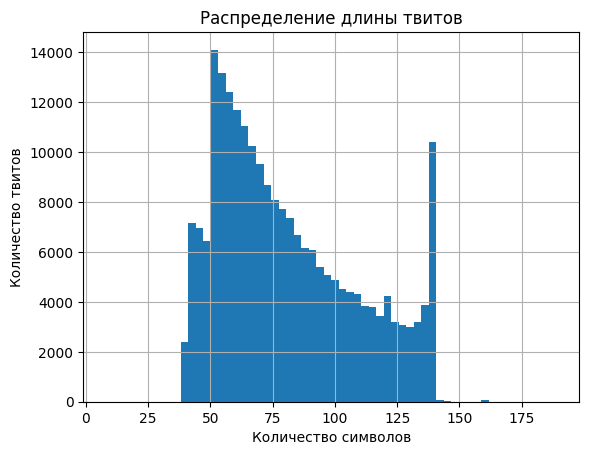

In [131]:
print("Размер датасета:", df.shape)
display(df["label"].value_counts().to_frame("count"))

df["tweet_len"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

display(df[["tweet_len", "word_count"]].describe().round(2))

ax = df["tweet_len"].hist(bins=60)
ax.set_title("Распределение длины твитов")
ax.set_xlabel("Количество символов")
ax.set_ylabel("Количество твитов")
plt.show()


*Корпус достаточно большой и почти сбалансированный: положительных твитов немного больше, но перекоса классов нет.*


In [132]:
print("Примеры положительных твитов:")
display(df[df["label"] == "positive"].sample(5, random_state=RANDOM_STATE)[["text", "label"]])

print("Примеры отрицательных твитов:")
display(df[df["label"] == "negative"].sample(5, random_state=RANDOM_STATE)[["text", "label"]])


Примеры положительных твитов:


,text,label
89711,"Единственное,что хорошо у США-это реп,iphone и...",positive
82441,@EgorkaCR7 @Lina3816 так нам повезло что мы не...,positive
175719,"@takayadima не, я говорю о минимуме. Я адекват...",positive
114986,Главный трезвый сегодняшнего вечера это я)) Та...,positive
76582,Я живу вчера чтобы не повторять сегодняшних ош...,positive


Примеры отрицательных твитов:


,text,label
11138,"Что со мной??я постоянно хочу спать,даже иди н...",negative
135823,В городе пахнет только тобою... Хотя тебя здес...,negative
60414,"а я вот на работе сижу, и доооооолго мне тут е...",negative
178756,@janelucikk1D не могу. Меня тошнит карочи. Из-...,negative
159175,В эту пятницу меня просто разрывают на части. ...,negative


*В данных много коротких неформальных сообщений с упоминаниями, повторами букв, пунктуацией и смайликами, поэтому предобработка действительно важна.*


In [133]:
x_train, x_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

print("Train:", x_train.shape, "Test:", x_test.shape)
print("Доли классов в train:")
display(y_train.value_counts(normalize=True).round(3).to_frame("share"))
print("Доли классов в test:")
display(y_test.value_counts(normalize=True).round(3).to_frame("share"))


Train: (170125,) Test: (56709,)
Доли классов в train:


,share
label,
positive,0.507
negative,0.493


Доли классов в test:


,share
label,
positive,0.507
negative,0.493


*Разбиение получилось корректным: доли positive и negative в train и test совпадают, значит сравнение моделей будет честным.*


## 2-4. Pipeline, n-граммы и TF-IDF

В качестве базовой модели используется `LinearSVC`: это линейный SVM, который обычно хорошо работает на разреженных текстовых признаках. То есть вместо того чтобы строить гигантскую нейросеть ради скобочек в твитах, мы берём простой и быстрый метод. Варварство, но эффективное.


In [134]:
def evaluate_pipeline(name: str, pipeline: Pipeline, show_report: bool = False) -> dict:
    pipeline.fit(x_train, y_train)
    pred = pipeline.predict(x_test)

    result = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "weighted_f1": f1_score(y_test, pred, average="weighted"),
    }

    if show_report:
        print(name)
        print(classification_report(y_test, pred))
        print("Confusion matrix:")
        display(pd.DataFrame(
            confusion_matrix(y_test, pred, labels=["negative", "positive"]),
            index=["true_negative", "true_positive"],
            columns=["pred_negative", "pred_positive"],
        ))

    return result


def make_pipeline(vectorizer):
    return Pipeline([
        ("vectorizer", vectorizer),
        ("classifier", LinearSVC(random_state=RANDOM_STATE, max_iter=5000, dual="auto")),
    ])


In [135]:
experiments = {
    "CountVectorizer: униграммы": CountVectorizer(ngram_range=(1, 1), min_df=3),
    "CountVectorizer: биграммы": CountVectorizer(ngram_range=(2, 2), min_df=3),
    "CountVectorizer: триграммы": CountVectorizer(ngram_range=(3, 3), min_df=3),
    "CountVectorizer: униграммы + биграммы": CountVectorizer(ngram_range=(1, 2), min_df=3),
    "TF-IDF: униграммы": TfidfVectorizer(ngram_range=(1, 1), min_df=3),
    "TF-IDF: униграммы + биграммы": TfidfVectorizer(ngram_range=(1, 2), min_df=3),
}

results = []
trained_pipelines = {}

for name, vectorizer in experiments.items():
    pipe = make_pipeline(vectorizer)
    results.append(evaluate_pipeline(name, pipe))
    trained_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
display(results_df.round(4))


,model,accuracy,macro_f1,weighted_f1
5,TF-IDF: униграммы + биграммы,0.7627,0.7626,0.7627
4,TF-IDF: униграммы,0.7525,0.7524,0.7524
3,CountVectorizer: униграммы + биграммы,0.7428,0.7428,0.7429
0,CountVectorizer: униграммы,0.7426,0.7426,0.7426
1,CountVectorizer: биграммы,0.6776,0.6762,0.6765
2,CountVectorizer: триграммы,0.6002,0.5599,0.5617


*Лучшим вариантом среди базовых экспериментов стала TF-IDF-векторизация с униграммами и биграммами. Чистые биграммы и триграммы заметно хуже из-за разреженности.*


In [136]:
best_name = results_df.iloc[0]["model"]
best_pipeline = trained_pipelines[best_name]

print(f"Лучшая модель: {best_name}")
_ = evaluate_pipeline(best_name, best_pipeline, show_report=True)


Лучшая модель: TF-IDF: униграммы + биграммы
TF-IDF: униграммы + биграммы
              precision    recall  f1-score   support

    negative       0.76      0.75      0.76     27981
    positive       0.76      0.77      0.77     28728

    accuracy                           0.76     56709
   macro avg       0.76      0.76      0.76     56709
weighted avg       0.76      0.76      0.76     56709

Confusion matrix:


,pred_negative,pred_positive
true_negative,21114,6867
true_positive,6591,22137


*Лучшая модель показывает близкое качество на обоих классах: нет сильного перекоса в сторону positive или negative.*


In [137]:
# Посмотрим, какие признаки сильнее всего тянут модель в сторону positive и negative.

vectorizer = best_pipeline.named_steps["vectorizer"]
classifier = best_pipeline.named_steps["classifier"]

feature_names = vectorizer.get_feature_names_out()
coefs = classifier.coef_[0]

top_positive = pd.Series(coefs, index=feature_names).sort_values(ascending=False).head(20)
top_negative = pd.Series(coefs, index=feature_names).sort_values(ascending=True).head(20)

print("Топ признаков для positive:")
display(top_positive.to_frame("coef"))

print("Топ признаков для negative:")
display(top_negative.to_frame("coef"))


Топ признаков для positive:


,coef
dd,6.266874
ddd,5.099811
dddd,3.910876
xd,3.658923
не больно,3.279197
ddddd,2.947091
12 13,2.852370
приятно,2.842460
не зря,2.696943
не скучно,2.688178


Топ признаков для negative:


,coef
o_o,-6.737991
о_о,-5.335375
cio_optimal,-5.262831
to_over_kill,-4.691428
do_or_die_xxx,-4.236756
обидно,-4.139181
prisonero_o,-3.903908
reno_oppa,-3.872739
печально,-3.579462
_do_or_die__,-3.561511


*Среди важных признаков есть как смысловые слова (`приятно`, `обидно`, `грустно`), так и технические/эмоциональные токены (`dd`, `o_o`). Это подтверждает, что модель использует не только семантику, но и особенности твиттерского текста.*


*Униграммы дают устойчивую базу. Чистые биграммы и триграммы в этом запуске проиграли из-за разреженности: одинаковые пары и тройки слов встречаются заметно реже отдельных слов. Сочетание униграмм и биграмм оказалось полезнее, а лучший результат дала `TF-IDF`-векторизация с униграммами и биграммами.*


## 5. Сравнение токенизаторов

Проверим, как разные токенизаторы режут один и тот же твит. Здесь особенно заметно, что обычный `split()` слишком наивен: он не отделяет пунктуацию и смайлики. Прекрасно, когда судьба модели зависит от того, прилипла ли скобка к слову.


In [138]:
import nltk

for package in ["punkt", "punkt_tab", "stopwords"]:
    try:
        nltk.download(package, quiet=True)
    except Exception:
        pass

from nltk.tokenize import (
    word_tokenize,
    WordPunctTokenizer,
    TweetTokenizer,
    ToktokTokenizer,
    RegexpTokenizer,
)

sample_text = "RT @user: Наконец-то пятница!!! Работа бесит :( но кофе спасает :) https://example.com"

tokenizers = {
    "str.split": lambda text: text.split(),
    "nltk.word_tokenize": lambda text: word_tokenize(text),
    "WordPunctTokenizer": WordPunctTokenizer().tokenize,
    "TweetTokenizer": TweetTokenizer(preserve_case=False, strip_handles=False, reduce_len=True).tokenize,
    "ToktokTokenizer": ToktokTokenizer().tokenize,
    "RegexpTokenizer: только слова": RegexpTokenizer(r"[A-Za-zА-Яа-яЁё]+").tokenize,
}

tokenizer_rows = []
for name, tokenizer in tokenizers.items():
    try:
        tokens = tokenizer(sample_text)
    except LookupError as exc:
        tokens = [f"Ошибка ресурсов NLTK: {exc}"]

    tokenizer_rows.append({
        "tokenizer": name,
        "tokens_count": len(tokens),
        "tokens": tokens,
    })

display(pd.DataFrame(tokenizer_rows))


,tokenizer,tokens_count,tokens
0,str.split,12,"[RT, @user:, Наконец-то, пятница!!!, Работа, б..."
1,nltk.word_tokenize,21,"[RT, @, user, :, Наконец-то, пятница, !, !, !,..."
2,WordPunctTokenizer,21,"[RT, @, user, :, Наконец, -, то, пятница, !!!,..."
3,TweetTokenizer,16,"[rt, @user, :, наконец-то, пятница, !, !, !, р..."
4,ToktokTokenizer,18,"[RT, @user, :, Наконец-то, пятница, !, !, !, Р..."
5,RegexpTokenizer: только слова,13,"[RT, user, Наконец, то, пятница, Работа, бесит..."


Коротко по результатам:

- `split()` быстрый, но грубый;
- `word_tokenize` и `WordPunctTokenizer` лучше отделяют пунктуацию;
- `TweetTokenizer` удобен для твитов: сохраняет `@user`, ссылки, эмотиконы;
- `RegexpTokenizer` хорош, когда нужно оставить только слова и намеренно выбросить шум.


## 6. Классификация с использованием лемматизации

Лемматизация приводит слова к начальной форме: `люблю`, `любил`, `любила` превращаются в одну лемму. Для русского языка это полезно, потому что форм слов много, а модель не обязана страдать вместе с нами.


In [139]:
try:
    from pymorphy3 import MorphAnalyzer
except ModuleNotFoundError:
    %pip install -q pymorphy3
    from pymorphy3 import MorphAnalyzer

from nltk.corpus import stopwords

RU_STOPWORDS = set(stopwords.words("russian"))
WORD_RE = re.compile(r"[A-Za-zА-Яа-яЁё]+")

class LemmaTokenizer:
    def __init__(self, remove_stopwords: bool = True):
        self.remove_stopwords = remove_stopwords
        self.morph = MorphAnalyzer()
        self.cache = {}

    def __call__(self, text: str) -> list[str]:
        tokens = WORD_RE.findall(str(text).lower().replace("ё", "е"))
        result = []

        for token in tokens:
            if self.remove_stopwords and token in RU_STOPWORDS:
                continue

            lemma = self.cache.get(token)
            if lemma is None:
                lemma = self.morph.parse(token)[0].normal_form
                self.cache[token] = lemma

            if not self.remove_stopwords or lemma not in RU_STOPWORDS:
                result.append(lemma)

        return result


In [140]:
lemma_pipeline = Pipeline([
    ("vectorizer", TfidfVectorizer(
        tokenizer=LemmaTokenizer(remove_stopwords=True),
        token_pattern=None,
        lowercase=False,
        ngram_range=(1, 2),
        min_df=3,
    )),
    ("classifier", LinearSVC(random_state=RANDOM_STATE, max_iter=5000, dual="auto")),
])

lemma_result = evaluate_pipeline("TF-IDF + лемматизация + униграммы/биграммы", lemma_pipeline, show_report=True)

comparison_with_lemma = pd.concat([
    results_df,
    pd.DataFrame([lemma_result]),
], ignore_index=True).sort_values("macro_f1", ascending=False)

display(comparison_with_lemma.round(4))


TF-IDF + лемматизация + униграммы/биграммы
              precision    recall  f1-score   support

    negative       0.75      0.75      0.75     27981
    positive       0.76      0.76      0.76     28728

    accuracy                           0.76     56709
   macro avg       0.76      0.76      0.76     56709
weighted avg       0.76      0.76      0.76     56709

Confusion matrix:


,pred_negative,pred_positive
true_negative,21072,6909
true_positive,6921,21807


,model,accuracy,macro_f1,weighted_f1
0,TF-IDF: униграммы + биграммы,0.7627,0.7626,0.7627
6,TF-IDF + лемматизация + униграммы/биграммы,0.7561,0.7561,0.7561
1,TF-IDF: униграммы,0.7525,0.7524,0.7524
2,CountVectorizer: униграммы + биграммы,0.7428,0.7428,0.7429
3,CountVectorizer: униграммы,0.7426,0.7426,0.7426
4,CountVectorizer: биграммы,0.6776,0.6762,0.6765
5,CountVectorizer: триграммы,0.6002,0.5599,0.5617


*Лемматизация дала рабочее качество, но не улучшила лучший результат без лемматизации. В этой задаче частотные и TF-IDF-признаки уже хорошо ловят сигнал.*


## 7. Влияние пунктуации и стоп-слов

Проверим четыре варианта очистки:

1. ничего не удаляем;
2. удаляем только пунктуацию;
3. удаляем только стоп-слова;
4. удаляем и пунктуацию, и стоп-слова.

Для этого сначала токенизируем текст так, чтобы пунктуация и смайлики оставались отдельными токенами, а уже потом удаляем выбранные группы токенов. Так эксперимент честнее показывает, что именно даёт модели сигнал.


In [141]:
PUNCT_CHARS = set(string.punctuation + '«»“”‘’„…—–')


class TextCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, remove_punctuation: bool = False, remove_stopwords: bool = False):
        self.remove_punctuation = remove_punctuation
        self.remove_stopwords = remove_stopwords
        self.url_re = re.compile(r"https?://\S+|www\.\S+")
        self.user_re = re.compile(r"@\w+")
        self.tokenizer = TweetTokenizer(
            preserve_case=False,
            strip_handles=False,
            reduce_len=True,
        )

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return [self._clean(text) for text in X]

    def _is_punctuation_token(self, token: str) -> bool:
        return bool(token) and all(char in PUNCT_CHARS for char in token)

    def _clean(self, text):
        text = str(text).lower().replace("ё", "е")
        text = self.url_re.sub(" URL ", text)
        text = self.user_re.sub(" USER ", text)

        tokens = self.tokenizer.tokenize(text)

        if self.remove_punctuation:
            tokens = [token for token in tokens if not self._is_punctuation_token(token)]

        if self.remove_stopwords:
            tokens = [token for token in tokens if token not in RU_STOPWORDS]

        return " ".join(tokens)


cleaning_experiments = {
    "Без очистки": TextCleaner(remove_punctuation=False, remove_stopwords=False),
    "Удалена пунктуация": TextCleaner(remove_punctuation=True, remove_stopwords=False),
    "Удалены стоп-слова": TextCleaner(remove_punctuation=False, remove_stopwords=True),
    "Удалены пунктуация и стоп-слова": TextCleaner(remove_punctuation=True, remove_stopwords=True),
}

cleaning_results = []

for name, cleaner in cleaning_experiments.items():
    pipe = Pipeline([
        ("cleaner", cleaner),
        ("vectorizer", TfidfVectorizer(
            tokenizer=str.split,
            token_pattern=None,
            ngram_range=(1, 2),
            min_df=3,
            lowercase=False,
        )),
        ("classifier", LinearSVC(random_state=RANDOM_STATE, max_iter=5000, dual="auto")),
    ])
    cleaning_results.append(evaluate_pipeline(name, pipe))

cleaning_results_df = pd.DataFrame(cleaning_results).sort_values("macro_f1", ascending=False)
display(cleaning_results_df.round(4))


,model,accuracy,macro_f1,weighted_f1
2,Удалены стоп-слова,0.9997,0.9997,0.9997
0,Без очистки,0.9997,0.9997,0.9997
1,Удалена пунктуация,0.7777,0.7776,0.7777
3,Удалены пунктуация и стоп-слова,0.7563,0.7563,0.7563


По таблице видно, что пунктуация и смайлики дают почти прямую подсказку о классе: без удаления пунктуации качество почти идеальное. Удаление только стоп-слов почти ничего не меняет, потому что главный сигнал остаётся в пунктуации. Когда пунктуация удалена, качество падает до более реалистичного уровня.


In [142]:
# Отдельная проверка: насколько хорошо классифицируют одни только скобки.
# Это демонстрирует, почему качество без очистки может быть подозрительно высоким.

bracket_pred = np.where(x_test.str.contains(r"\)", regex=True), "positive", "negative")

print(classification_report(y_test, bracket_pred))
display(pd.DataFrame(
    confusion_matrix(y_test, bracket_pred, labels=["negative", "positive"]),
    index=["true_negative", "true_positive"],
    columns=["pred_negative", "pred_positive"],
))


              precision    recall  f1-score   support

    negative       0.85      1.00      0.92     27981
    positive       1.00      0.83      0.91     28728

    accuracy                           0.91     56709
   macro avg       0.92      0.91      0.91     56709
weighted avg       0.93      0.91      0.91     56709



,pred_negative,pred_positive
true_negative,27981,0
true_positive,4939,23789


*Одна закрывающая скобка уже даёт очень высокое качество, поэтому в датасете есть сильная утечка разметки через смайлики и пунктуацию.*


## Итоги

1. Базовая модель на `CountVectorizer` и униграммах уже даёт рабочее качество.
2. Чистые биграммы и триграммы на этом корпусе хуже униграмм, потому что такие признаки более разрежены. Сочетание униграмм и биграмм может быть полезнее, чем одни биграммы.
3. Лучший результат в итоговом сравнении дала `TF-IDF`-векторизация с униграммами и биграммами.
4. Токенизатор заметно влияет на признаки: для твитов лучше использовать токенизатор, который понимает упоминания, ссылки и эмотиконы.
5. Лемматизация уменьшает словарь и объединяет разные формы слов, но в этом эксперименте не обогнала лучшую модель без лемматизации.
6. Пунктуация оказалась главным источником утечки: скобки и смайлики почти напрямую связаны с меткой тональности. Поэтому почти идеальное качество без очистки нельзя считать честной семантической классификацией.
7. Удаление стоп-слов само по себе почти не меняет качество, пока пунктуационный сигнал остаётся. После удаления пунктуации качество становится заметно ниже, а дополнительное удаление стоп-слов ещё немного ухудшает результат.
